# Финальная работа — Airbnb NYC (AB_NYC_2019)

## Установка зависимостей

In [1]:
!pip install kagglehub umap-learn hdbscan plotly --quiet

## Загрузка датасета

In [2]:
import os, pandas as pd
import kagglehub

path = kagglehub.dataset_download('dgomonov/new-york-city-airbnb-open-data')
csv_path = os.path.join(path, 'AB_NYC_2019.csv')
df = pd.read_csv(csv_path)

print('Размер датасета:', df.shape)
df.head()


Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Размер датасета: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Обзор датасета

In [10]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


Вывод:
- Например, по price(цена):
Средняя цена — около $152, но максимум $10,000 и стандартное отклонение 240 говорят о сильных выбросах (например, люксовые апартаменты). Такие экстремальные значения можно будет обработать (например, обрезать или логарифмировать).
- minimum_nights. Среднее — 7 ночей, но есть объявления, где минимум — 1250 ночей. Это явно выбросы (возможно, некорректные данные или владельцы хотят сдавать только на длительный срок).
- number_of_reviews. Среднее количество отзывов — 23, но есть квартиры с 629 отзывами. Медиана — 5, значит, распределение с сильным перекосом: большинство объявлений имеет мало отзывов.
- reviews_per_month. Среднее — 1.37, максимум — 58.5. У части записей отсутствует (NaN, видно по count = 38843 < 48895). Это значит, что не у всех объявлений есть активность в виде отзывов, возможно, они новые или неактивные.

In [11]:
# Описательная статистика для категориальных признаков (текстовых столбцов).
df.describe(include='object')

,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review
count,48879,48874,48895,48895,48895,38843
unique,47905,11452,5,221,3,1764
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt,2019-06-23
freq,18,417,21661,3920,25409,1413


Вывод:
- host_name. Имена не уникальны — могут повторяться (разные Майклы). Лучше использовать host_id, а не имя.

- top - наиболее частое
- freq - частота

In [12]:
# Демонстрируем информацию о колонках
df.info()

df[['neighbourhood_group','room_type','price','minimum_nights','number_of_reviews','reviews_per_month','availability_365']].describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

,neighbourhood_group,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365
count,48895,48895,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000
unique,5,3,NaN,NaN,NaN,NaN,NaN
top,Manhattan,Entire home/apt,NaN,NaN,NaN,NaN,NaN
freq,21661,25409,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,152.720687,7.029962,23.274466,1.373221,112.781327
std,NaN,NaN,240.154170,20.510550,44.550582,1.680442,131.622289
min,NaN,NaN,0.000000,1.000000,0.000000,0.010000,0.000000
25%,NaN,NaN,69.000000,1.000000,1.000000,0.190000,0.000000
50%,NaN,NaN,106.000000,3.000000,5.000000,0.720000,45.000000
75%,NaN,NaN,175.000000,5.000000,24.000000,2.020000,227.000000


In [13]:
df.duplicated().sum()

np.int64(0)

<Axes: >

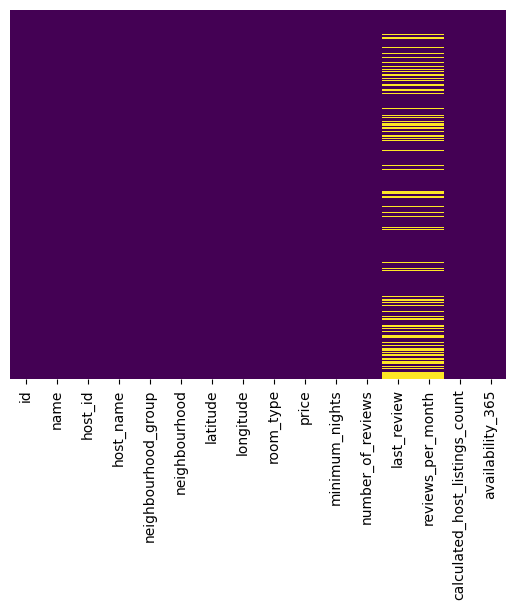

In [14]:
# Посморим на то, где у нас отсутствуют значения вообще
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [15]:
df.isna().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [16]:
print('\nПропуски (количество):')
print(df.isnull().sum().sort_values(ascending=False).head(10))


Пропуски (количество):
last_review            10052
reviews_per_month      10052
host_name                 21
name                      16
neighbourhood_group        0
neighbourhood              0
id                         0
host_id                    0
longitude                  0
latitude                   0
dtype: int64


In [3]:
# метод, который заменяет все пропущенные значения (NaN) на указанный текст 'unknown'

df['name']=df['name'].fillna('unknown')
df['host_name']=df['host_name'].fillna('unknown')

len(df.loc[df['host_name']=='unknown','host_name'])

21

In [19]:
df.isna().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [4]:
df[df['last_review'].isna()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
19,7750,Huge 2 BR Upper East Cental Park,17985,Sing,Manhattan,East Harlem,40.79685,-73.94872,Entire home/apt,190,7,0,NaN,NaN,2,249
26,8700,Magnifique Suite au N de Manhattan - vue Cloitres,26394,Claude & Sophie,Manhattan,Inwood,40.86754,-73.92639,Private room,80,4,0,NaN,NaN,1,0
36,11452,Clean and Quiet in Brooklyn,7355,Vt,Brooklyn,Bedford-Stuyvesant,40.68876,-73.94312,Private room,35,60,0,NaN,NaN,1,365
38,11943,Country space in the city,45445,Harriet,Brooklyn,Flatbush,40.63702,-73.96327,Private room,150,1,0,NaN,NaN,1,365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [5]:
# df.loc[df['number_of_reviews']==0,'reviews_per_month']

df.loc[df['number_of_reviews']==0,'reviews_per_month']=0.0

In [24]:
df.isna().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [6]:
df[df['last_review'].isna()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.0,1,365
19,7750,Huge 2 BR Upper East Cental Park,17985,Sing,Manhattan,East Harlem,40.79685,-73.94872,Entire home/apt,190,7,0,NaN,0.0,2,249
26,8700,Magnifique Suite au N de Manhattan - vue Cloitres,26394,Claude & Sophie,Manhattan,Inwood,40.86754,-73.92639,Private room,80,4,0,NaN,0.0,1,0
36,11452,Clean and Quiet in Brooklyn,7355,Vt,Brooklyn,Bedford-Stuyvesant,40.68876,-73.94312,Private room,35,60,0,NaN,0.0,1,365
38,11943,Country space in the city,45445,Harriet,Brooklyn,Flatbush,40.63702,-73.96327,Private room,150,1,0,NaN,0.0,1,365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,0.0,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,0.0,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,0.0,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,0.0,6,2


In [7]:
df.loc[df['last_review'].isna(),'last_review']='1950-1-1'

df['last_review']=pd.to_datetime(df['last_review'],errors='coerce')

df.isna().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [8]:
df[df['price']==0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.05,4,28
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2019-06-24,2.56,4,127
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,2019-05-18,0.71,5,0
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.53,2,0
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,2018-01-02,0.15,1,73
25794,20639628,Spacious comfortable master bedroom with nice ...,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,2019-06-15,4.28,6,176
25795,20639792,Contemporary bedroom in brownstone with nice view,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,2019-06-21,4.37,6,232
25796,20639914,Cozy yet spacious private brownstone bedroom,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,2019-06-23,4.35,6,222
26259,20933849,the best you can find,13709292,Qiuchi,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,1950-01-01,0.00,1,0
26841,21291569,Coliving in Brooklyn! Modern design / Shared room,101970559,Sergii,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,2019-06-22,0.11,6,333


In [13]:
df.loc[df['price']==0,'price']=np.nan

# берём среднюю цену только для конкретного района и типа жилья.
df['price']=df.groupby(['room_type','neighbourhood'])['price'].transform(lambda x: x.fillna(x.mean()))

df.loc[df['price']==0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


## EDA — визуализации

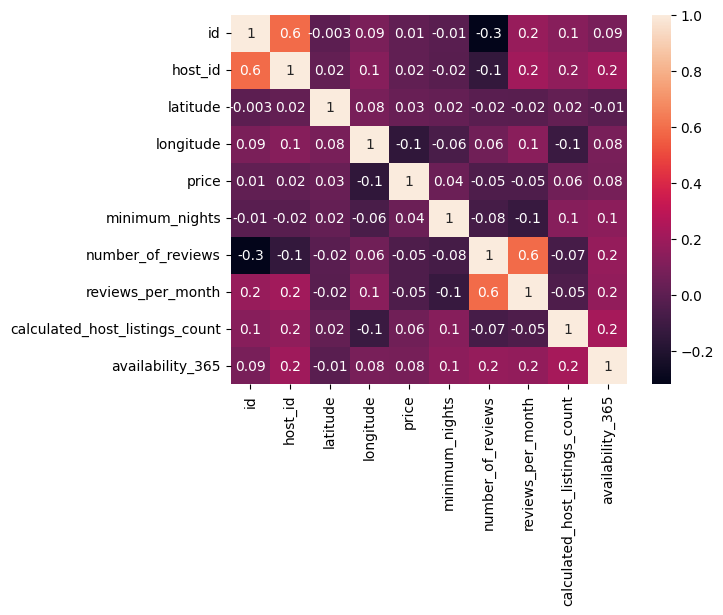

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Матрица корреляций
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.1g')
plt.show()

- number_of_reviews и reviews_per_month: 0.6 → чем больше отзывов всего, тем больше среднее количество отзывов в месяц.
- latitude и longitude практически не коррелируют ни с чем (значения около 0).
- price, minimum_nights почти не коррелируют с другими признаками.

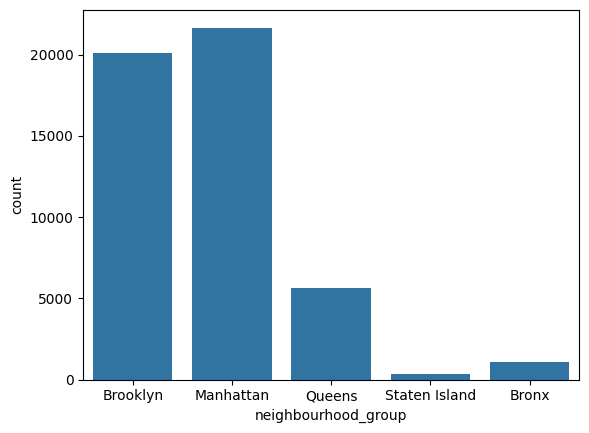

In [34]:
sns.countplot(data=df,x='neighbourhood_group')
plt.show()

На графике показано количество объектов в районах Нью-Йорка. Больше всего объектов находится в Манхэттене и Бруклине, значительно меньше — в Квинсе, а в Стейтен-Айленде и Бронксе их минимальное количество.

In [35]:
d=df['neighbourhood'].value_counts().reset_index().head(10)
d

,neighbourhood,count
0,Williamsburg,3920
1,Bedford-Stuyvesant,3714
2,Harlem,2658
3,Bushwick,2465
4,Upper West Side,1971
5,Hell's Kitchen,1958
6,East Village,1853
7,Upper East Side,1798
8,Crown Heights,1564
9,Midtown,1545


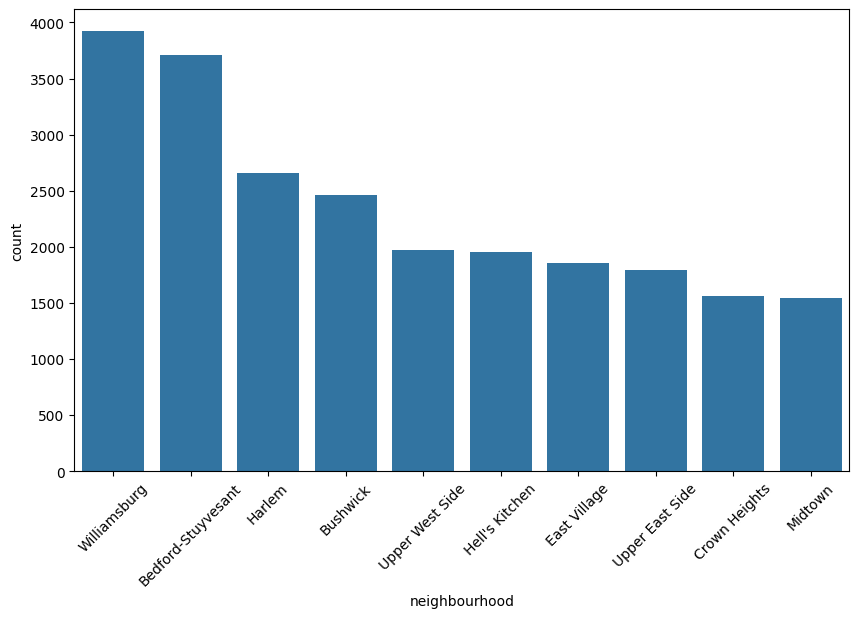

In [36]:
# 10 лучших районов

plt.figure(figsize=(10,6))
sns.barplot(data=d,x='neighbourhood',y='count')
plt.xticks(rotation=45)
plt.show()

In [37]:
d=df.pivot_table(index='neighbourhood_group',values='price',aggfunc='sum')
d=d.reset_index()
d

,neighbourhood_group,price
0,Bronx,9.553733e+04
1,Brooklyn,2.501328e+06
2,Manhattan,4.264765e+06
3,Queens,5.638670e+05
4,Staten Island,4.282500e+04


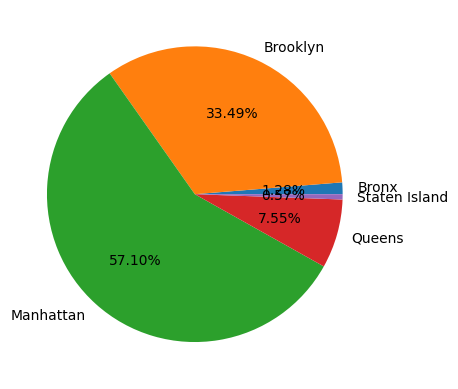

In [38]:
plt.pie(data=d,x='price',labels=d['neighbourhood_group'],autopct='%1.2f%%')
plt.show()

In [39]:
df.loc[df['price']==df['price'].max(),'neighbourhood']

,neighbourhood
9151,Astoria
17692,Greenpoint
29238,Upper West Side


In [40]:
df.loc[df['price']==df['price'].min(),'neighbourhood']

,neighbourhood
2860,East Village
21700,Harlem
22261,Bushwick
22287,SoHo
22835,Jamaica
23256,Upper East Side
24100,Hell's Kitchen
27972,Greenpoint
31066,Upper West Side
31407,Kips Bay


In [41]:
d=df['room_type'].value_counts().reset_index()
d

,room_type,count
0,Entire home/apt,25409
1,Private room,22326
2,Shared room,1160


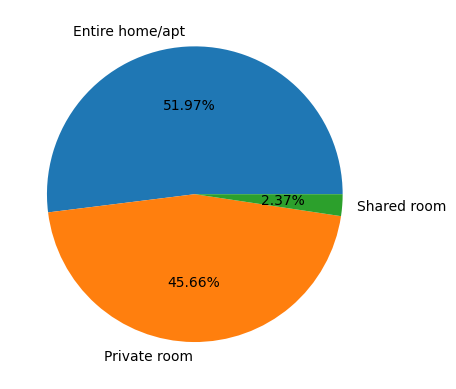

In [42]:
plt.pie(data=d,x='count',labels=d['room_type'],autopct='%1.2f%%')
plt.show()

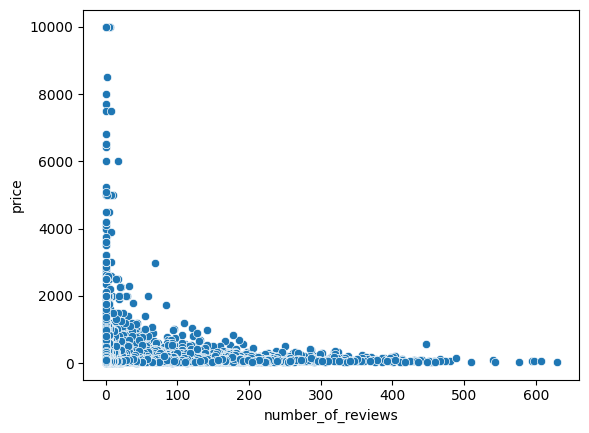

In [43]:
sns.scatterplot(data=df,x='number_of_reviews',y='price')
plt.show()

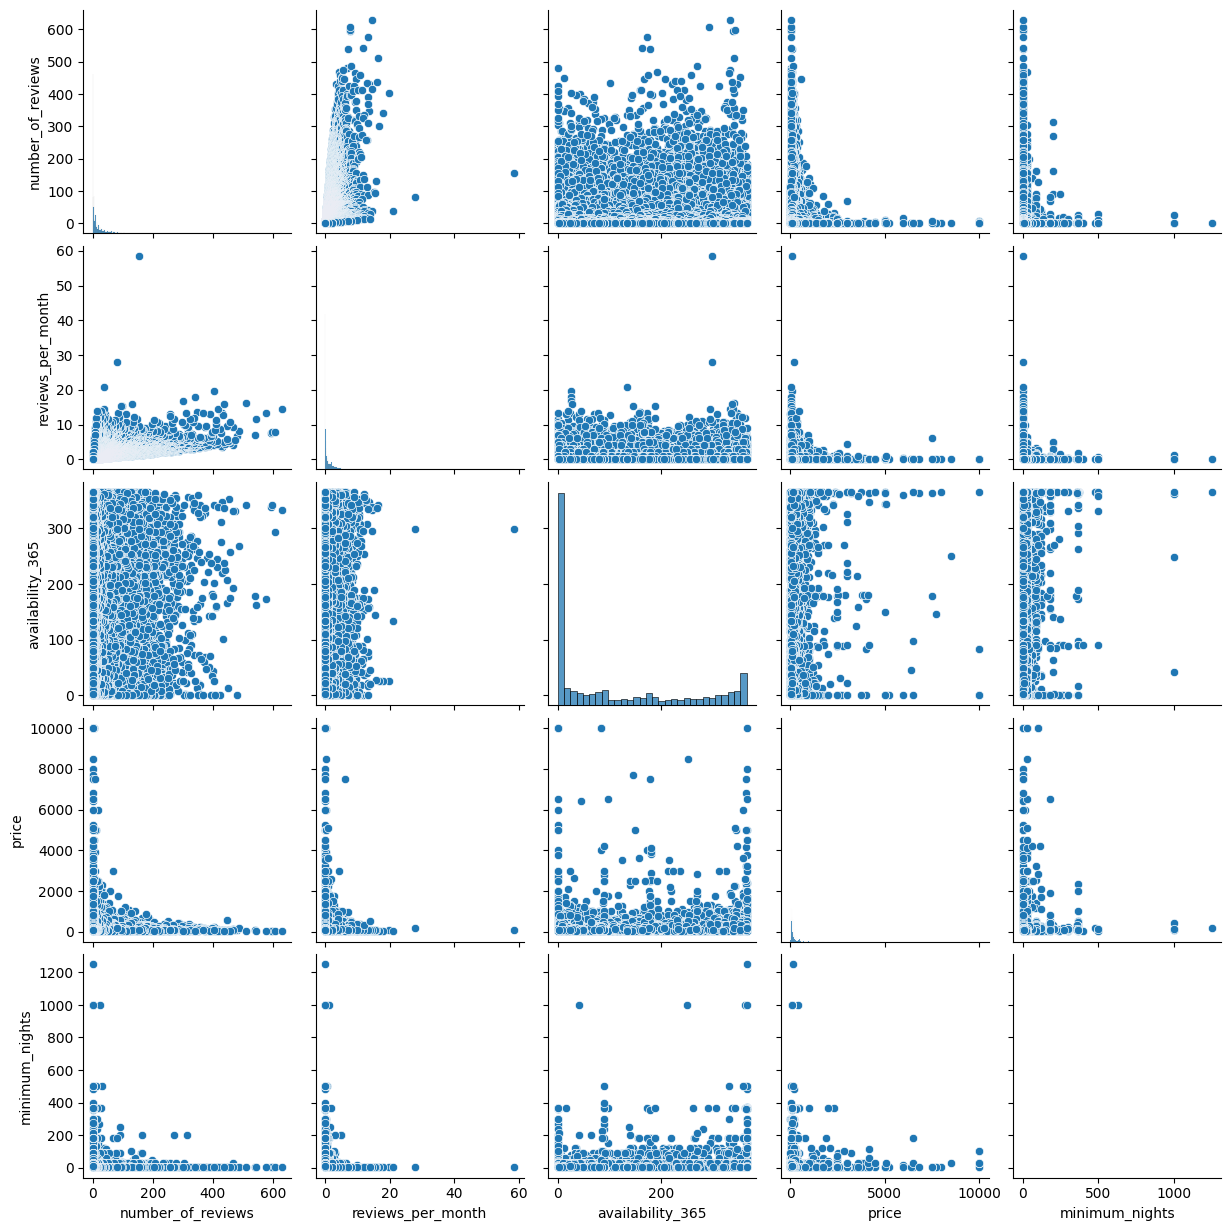

In [44]:
sns.pairplot(df[['number_of_reviews','reviews_per_month','availability_365','price','minimum_nights']])
plt.show()

## Предобработка и фичи
Заполним пропуски, создадим log_price и индикатор наличия отзывов (has_reviews).

In [10]:
import numpy as np

data = df.copy()
# data['reviews_per_month'] = data['reviews_per_month'].fillna(0)
data = data.dropna(subset=['latitude','longitude'])
# Цена обычно сильно распределена с длинным хвостом.
# Логарифм помогает сгладить распределение и уменьшить влияние выбросов на модель.
data['log_price'] = np.log1p(data['price'])
# Создаётся бинарная переменная: есть отзывы (1) или нет (0). Это может быть полезно для модели.
data['has_reviews'] = (data['number_of_reviews'] > 0).astype(int)

print('После предобработки размер:', data.shape)
display(data[['price','log_price','number_of_reviews','reviews_per_month','has_reviews']].head())


После предобработки размер: (48895, 18)


,price,log_price,number_of_reviews,reviews_per_month,has_reviews
0,149,5.010635,9,0.21,1
1,225,5.420535,45,0.38,1
2,150,5.017280,0,0.00,0
3,89,4.499810,270,4.64,1
4,80,4.394449,9,0.10,1


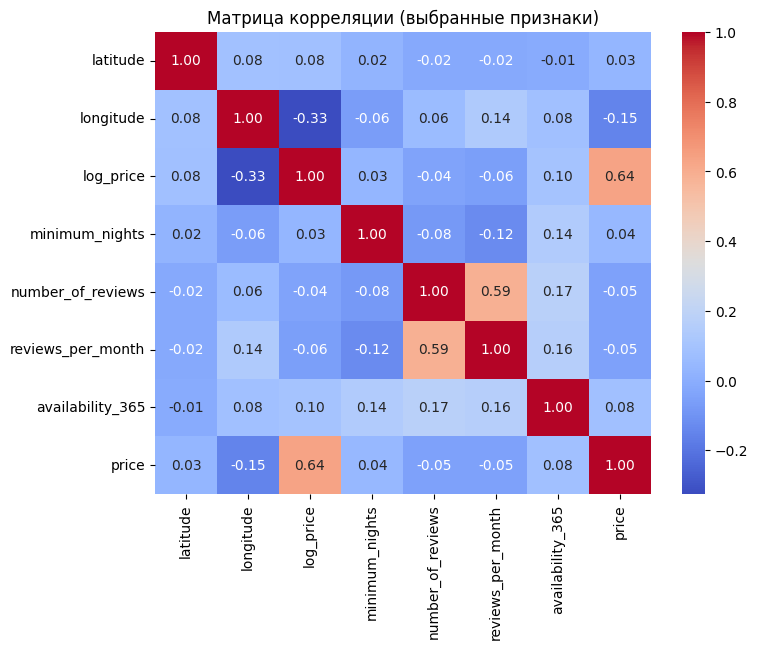

Топ корреляций с ценой:
price                1.000000
log_price            0.637669
longitude            0.150019
availability_365     0.081829
reviews_per_month    0.050564
number_of_reviews    0.047954
minimum_nights       0.042799
latitude             0.033939
Name: price, dtype: float64


In [16]:
feat_for_corr = ['latitude','longitude','log_price','minimum_nights','number_of_reviews','reviews_per_month','availability_365']
cor_df = data[feat_for_corr + ['price']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(cor_df, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Матрица корреляции (выбранные признаки)')
plt.show()

print('Топ корреляций с ценой:')
print(cor_df['price'].abs().sort_values(ascending=False))


Преобразование цены в логарифм даёт умеренную положительную корреляцию с исходной ценой. Это логично: log_price — просто монотонная функция от price.

- longitude – 0.15.
Географическая долгота немного влияет на цену. То есть местоположение по горизонтали (восток-запад) играет роль, но слабую.
- availability_365 – 0.082.
Количество дней в году, когда жильё доступно, почти не влияет на цену. Очень слабая положительная связь.
- reviews_per_month – 0.051.
Среднее количество отзывов в месяц тоже слабо связано с ценой. Возможно, больше популярные объекты чуть дороже, но эффект маленький.
- number_of_reviews – 0.048.
Общее количество отзывов почти не влияет на цену.

## Подготовка признаков для кластеризации
One-hot кодируем `neighbourhood_group` и `room_type`, собираем финальный набор признаков и стандартизируем их.

In [17]:
cat_cols = ['neighbourhood_group','room_type']
for c in cat_cols:
    data[c] = data[c].astype('category')

data_model = pd.get_dummies(data, columns=cat_cols, drop_first=True)
features = ['latitude','longitude','log_price','minimum_nights','number_of_reviews','reviews_per_month','availability_365']
dummy_cols = [c for c in data_model.columns if 'neighbourhood_group_' in c or 'room_type_' in c]
features += dummy_cols

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
# SimpleImputer: заменяет оставшиеся пропуски медианой.
# StandardScaler: стандартизирует данные (среднее = 0, стандартное отклонение = 1).
X = data_model[features].copy()
imp = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns)

print('Признаки для кластеризации подготовлены, форма:', X_scaled.shape)
X_scaled.head()


Признаки для кластеризации подготовлены, форма: (48895, 13)


,latitude,longitude,log_price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,-1.493849,-0.437652,0.393695,-0.293996,-0.320414,-0.551511,1.916250,1.196705,-0.891833,-0.362035,-0.087677,1.090893,-0.155887
1,0.452436,-0.684639,0.983192,-0.293996,0.487665,-0.445079,1.840275,-0.835628,1.121286,-0.362035,-0.087677,-0.916680,-0.155887
2,1.468399,0.222497,0.403251,-0.196484,-0.522433,-0.682986,1.916250,-0.835628,1.121286,-0.362035,-0.087677,1.090893,-0.155887
3,-0.803398,-0.164450,-0.340950,-0.293996,5.538156,2.221978,0.617065,1.196705,-0.891833,-0.362035,-0.087677,-0.916680,-0.155887
4,1.275660,0.177216,-0.492474,0.144807,-0.320414,-0.620379,-0.856865,-0.835628,1.121286,-0.362035,-0.087677,-0.916680,-0.155887


## UMAP — визуализация многомерной структуры
UMAP помогает увидеть локальную структуру и потенциальные кластеры в 2D.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (48895, 2)


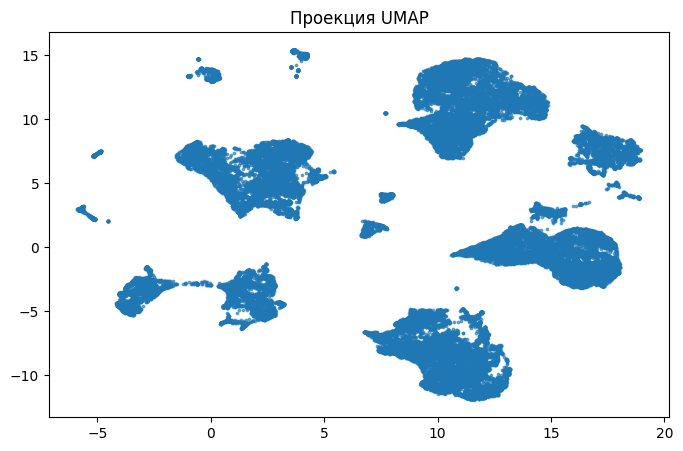

In [21]:
import umap  # Импортируем библиотеку UMAP для снижения размерности

# Создаём объект UMAP с заданными параметрами
reducer = umap.UMAP(
    n_neighbors=15,  # Количество соседей для построения локальной структуры данных
    min_dist=0.1,    # Минимальное расстояние между точками в 2D пространстве
    random_state=42  # Фиксируем случайность для воспроизводимости
)

# Применяем UMAP к подготовленным признакам (X_scaled)
# fit_transform обучает модель и возвращает данные в 2D пространстве
X_umap = reducer.fit_transform(X_scaled)

# Выводим форму полученного массива (количество объектов и размерность)
print('UMAP shape:', X_umap.shape)

plt.figure(figsize=(8,5))  # Размер графика 8x5 дюймов

plt.scatter(
    X_umap[:,0],  # Первая координата после UMAP
    X_umap[:,1],  # Вторая координата после UMAP
    s=3,          # Размер точек
    alpha=0.6     # Прозрачность точек
)

plt.title('Проекция UMAP')
plt.show()

## Кластеризация — 5 методов
Применим KMeans, Agglomerative, DBSCAN, GaussianMixture и HDBSCAN. Каждый метод имеет свои сильные стороны: KMeans — простота, DBSCAN — поиск по плотности, GMM — вероятностная модель.

In [49]:
pip install hdbscan

In [18]:
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN
from sklearn.mixture import GaussianMixture

# KMeans
kmeans = KMeans(n_clusters=6, random_state=42)
labels_km = kmeans.fit_predict(X_scaled)

# MiniBatchKMeans вместо AgglomerativeClustering
# проблемы с памятью на больших датасетах, потому что он строит полную матрицу попарных расстояний (n_samples × n_samples),
# 49 000 объектов → матрица ~2.4 млрд элементов.
mb_kmeans = MiniBatchKMeans(n_clusters=6, random_state=42, batch_size=1000)
labels_mb = mb_kmeans.fit_predict(X_scaled)

# DBSCAN
db = DBSCAN(eps=0.5, min_samples=10)
labels_db = db.fit_predict(X_scaled)

# Gaussian Mixture
gmm = GaussianMixture(n_components=6, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)

# HDBSCAN (опционально)
labels_hdb = None
try:
    import hdbscan
    hdb = hdbscan.HDBSCAN(min_cluster_size=50)
    labels_hdb = hdb.fit_predict(X_scaled)
    # Количество найденных кластеров (игнорируем -1 = шум)
    print('Количество кластеров HDBSCAN:', len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0))
except Exception as e:
    print('HDBSCAN недоступен:', e)

print('Кластеризация завершена')



/usr/local/lib/python3.12/dist-packages/hdbscan/plots.py:448: SyntaxWarning: invalid escape sequence '\l'
  axis.set_ylabel('$\lambda$ value')
/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Количество кластеров HDBSCAN: 13
Кластеризация завершена


## Визуализация кластеров на UMAP
Если кластеры на UMAP выглядят компактно — это хороший признак согласованности кластеризации.

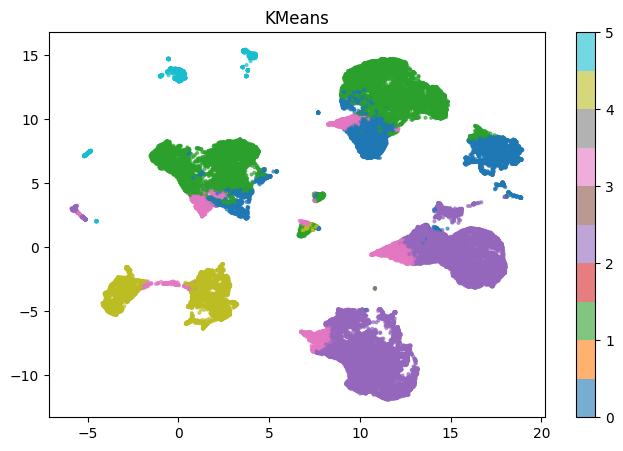

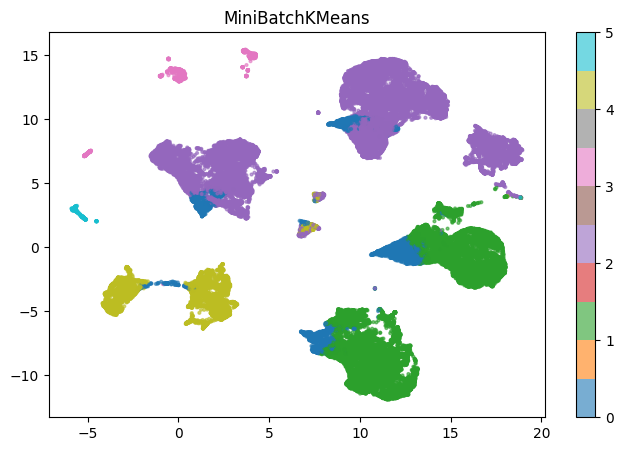

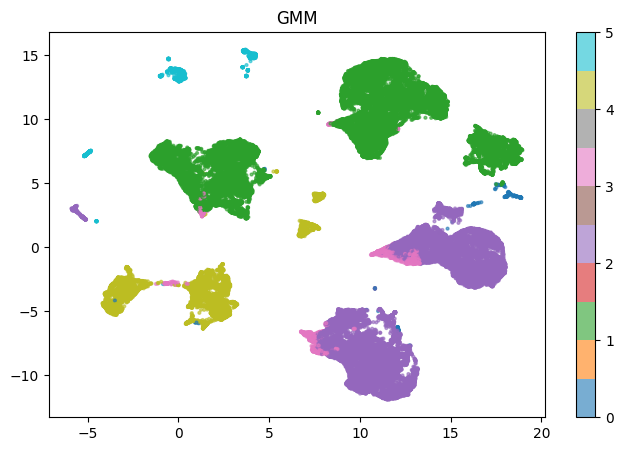

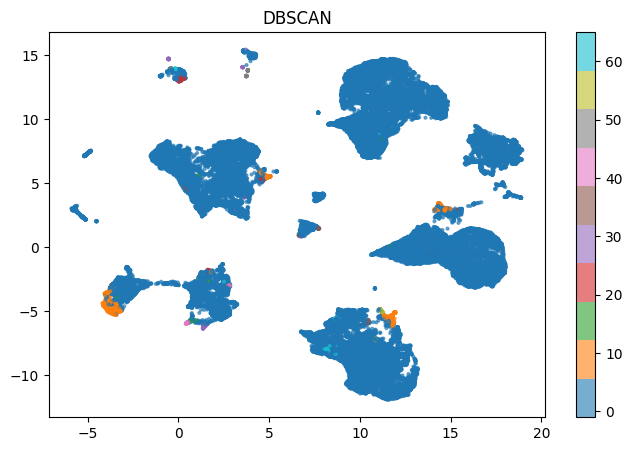

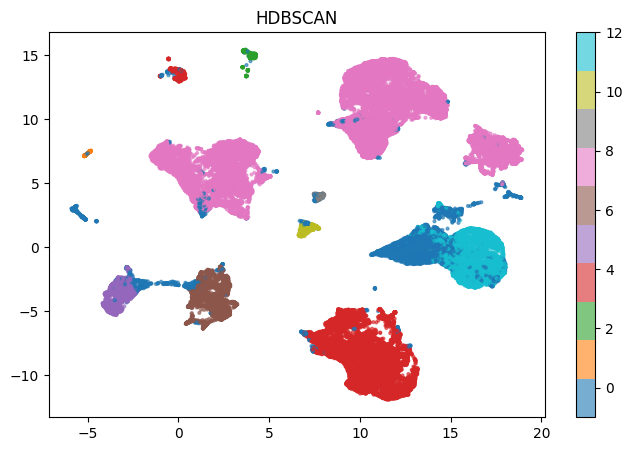

In [22]:
def plot_labels(labels, title):
    plt.figure(figsize=(8,5))
    plt.scatter(X_umap[:,0], X_umap[:,1], c=labels, cmap='tab10', s=4, alpha=0.6)
    plt.title(title)
    plt.colorbar()
    plt.show()

plot_labels(labels_km, 'KMeans')
plot_labels(labels_mb, 'MiniBatchKMeans')
plot_labels(labels_gmm, 'GMM')
plot_labels(labels_db, 'DBSCAN')
if labels_hdb is not None:
    plot_labels(labels_hdb, 'HDBSCAN')


## Анализ кластеров: средняя цена и размер
Посмотрим, какие кластеры более дорогие, а какие — доступные.

In [23]:
# Создаём копию исходного датасета, сбрасываем индекс
data2 = data_model.reset_index(drop=True).copy()

# Добавляем колонки с метками кластеров, полученных KMeans и GMM
data2['cluster_km'] = labels_km
data2['cluster_gmm'] = labels_gmm

# Группируем по кластерам KMeans и считаем:
# - среднюю цену ('price')
# - количество объектов в кластере ('id')
# - среднюю доступность в году ('availability_365')
# Переименовываем колонку 'id' в 'count' и сортируем по размеру кластера
summary_km = data2.groupby('cluster_km').agg({
    'price':'mean',
    'id':'count',
    'availability_365':'mean'
}).rename(columns={'id':'count'}).sort_values('count', ascending=False)

# Выводим сводку по кластерам KMeans
print('KMeans summary:')
display(summary_km)

# То же самое для GMM:
# Группируем по кластерам GMM и считаем среднюю цену и количество объектов
# Переименовываем 'id' в 'count' и сортируем по размеру кластера
print('\nGMM summary:')
display(
    data2.groupby('cluster_gmm').agg({'price':'mean','id':'count'})
         .rename(columns={'id':'count'})
         .sort_values('count', ascending=False)
)


KMeans summary:


,price,count,availability_365
cluster_km,,,
2,120.408878,18157,91.587046
1,145.090021,13919,34.704074
0,332.202316,6648,266.820548
4,96.540511,5480,144.054745
3,125.328050,3533,174.923578
5,70.120035,1158,161.660622



GMM summary:


,price,count
cluster_gmm,,
1,198.624014,20913
2,124.796954,18907
4,96.953966,6430
3,110.642799,1229
5,70.093184,1159
0,440.801556,257


KMeans:
- Выводы:

Крупные кластеры (2 и 1) — средние цены ~120–145, средняя доступность ~30–90 дней в году. Это типичные объекты для краткосрочной аренды.

Кластер 0 — очень дорогие объекты (332), с высокой доступностью (266 дней). Вероятно, это элитные или популярные квартиры/дома.

Кластер 5 — дешёвые объекты (~70) с высокой доступностью. Могут быть комнаты или недорогие варианты.

Кластеры с высокой availability_365 (0, 3, 5) — жильё, которое сдаётся почти весь год, возможно долгосрочные аренды или элитные объекты с стабильным спросом.

GMM:
- Выводы:

GMM формирует более выраженные кластеры по цене, особенно кластеры дорогих объектов (0 — почти 441$).

Большие кластеры (1 и 2) — средний сегмент жилья (~125–200$).

Малые кластеры (0, 3, 5) — либо элитные, либо очень дешёвые варианты, что говорит о том, что GMM хорошо отделяет "экстремальные" объекты.

# KMeans хорош для сегментации большинства объектов, GMM лучше для выявления "особенных" объектов и ценовых крайностей.

In [24]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np

# Соберём все алгоритмы в словарь
cluster_labels = {
    'KMeans': labels_km,
    'MiniBatchKMeans': labels_mb,
    'GMM': labels_gmm,
    'DBSCAN': labels_db
}

if labels_hdb is not None:
    cluster_labels['HDBSCAN'] = labels_hdb

# Функция для расчёта метрик, игнорируя шум (-1)
def compute_metrics(X, labels):
    # Игнорируем объекты с меткой -1 (шум)
    mask = labels != -1
    X_masked = X[mask]
    labels_masked = labels[mask]

    if len(set(labels_masked)) < 2:
        # Метрики нельзя посчитать, если меньше 2 кластеров
        return {'Silhouette': np.nan, 'Calinski-Harabasz': np.nan, 'Davies-Bouldin': np.nan}

    sil = silhouette_score(X_masked, labels_masked)
    ch = calinski_harabasz_score(X_masked, labels_masked)
    db = davies_bouldin_score(X_masked, labels_masked)
    return {'Silhouette': sil, 'Calinski-Harabasz': ch, 'Davies-Bouldin': db}

# Считаем метрики для всех алгоритмов
metrics_results = {}
for name, labels in cluster_labels.items():
    metrics_results[name] = compute_metrics(X_scaled, labels)

# Выводим результаты
import pandas as pd
metrics_df = pd.DataFrame(metrics_results).T
print(metrics_df)


                 Silhouette  Calinski-Harabasz  Davies-Bouldin
KMeans             0.271569        8607.267644        1.402920
MiniBatchKMeans    0.323696       10478.247470        1.111045
GMM                0.317944        7797.509136        1.161787
DBSCAN             0.091316        1306.795588        0.779868
HDBSCAN            0.278183        8045.699988        1.231287


- Silhouette Score — плотность и разделимость кластеров.

MiniBatchKMeans показывает лучший Silhouette Score (0.324), что говорит о более чётких и плотных кластерах.
DBSCAN низкий (0.091) — кластеры плохо отделяются или много шума.
KMeans и HDBSCAN — средние показатели, кластеры относительно понятные, но не очень плотные.

- Calinski-Harabasz Index — соотношение дисперсий между и внутри кластеров.

MiniBatchKMeans снова лучше, кластеры хорошо разделены и компактны.
DBSCAN очень низкий — кластеры либо размытые, либо малочисленные.
GMM немного хуже KMeans и MiniBatchKMeans.

- Davies-Bouldin Index — отношение внутрикластерного разброса к расстоянию между центрами кластеров.

DBSCAN имеет самый низкий индекс — формально кластеры компактные относительно расстояний между ними.
MiniBatchKMeans тоже хороший (1.111).
KMeans и HDBSCAN чуть хуже.
Но стоит помнить: для DBSCAN большинство точек может быть отнесено к шуму (-1), поэтому метрики могут вводить в заблуждение: низкий Davies-Bouldin не всегда означает хорошие кластеры по числу объектов.

## MiniBatchKMeans — лучший компромисс

## Ансамбль кластеров

In [28]:
import numpy as np
import pandas as pd

# Создаём DataFrame с метками кластеров от разных алгоритмов
labels_df = pd.DataFrame({
    'km': labels_km,        # KMeans
    'mb': labels_mb,        # MiniBatchKMeans
    'gmm': labels_gmm,      # GMM
    'db': labels_db         # DBSCAN
})

# Если HDBSCAN использовался, добавляем его метки
if labels_hdb is not None:
    labels_df['hdb'] = labels_hdb

# Преобразуем DataFrame меток в numpy массив и делаем его float, чтобы можно было использовать NaN
lab_matrix = labels_df.values.astype(float)

# Заменяем все шумовые метки (<0) на NaN
lab_matrix[lab_matrix < 0] = np.nan

# Функция для нахождения моды (наиболее частой метки) в строке
def row_mode(arr):
    """
    arr - одномерный массив меток кластеров для одного объекта
    Игнорирует NaN (шумовые точки), возвращает наиболее частую метку.
    Если меток нет (все NaN), возвращает -1
    """
    # Оставляем только валидные метки (не NaN)
    valid = arr[~np.isnan(arr)]

    if len(valid) == 0:
        return -1  # если нет валидных меток

    # Находим уникальные значения и их количество
    vals, counts = np.unique(valid, return_counts=True)

    # Возвращаем значение с максимальным количеством вхождений
    return vals[np.argmax(counts)]

# Вычисляем консенсусную метку для каждого объекта
consensus = np.array([row_mode(r) for r in lab_matrix])

# Добавляем эту консенсусную метку в основной датасет
data2['cluster_consensus'] = consensus

# Создаём сводку по консенсусным кластерам:
# - количество объектов в кластере ('count')
# - средняя цена ('price')
cons_summary = data2.groupby('cluster_consensus').agg({
    'id':'count',
    'price':'mean'
}).rename(columns={'id':'count'}).sort_values('count', ascending=False)

# Выводим сводную таблицу
display(cons_summary)


,count,price
cluster_consensus,,
2.0,17949,120.765335
1.0,17300,170.838150
0.0,5751,277.846288
4.0,5650,96.116460
3.0,1564,102.916240
5.0,681,62.038179


Консенсусная кластеризация выделяет 6 сегментов жилья по цене и размеру:

- Очень крупные средние сегменты (2.0 и 1.0)
- Дорогие объекты (0.0)
- Недорогие объекты (4.0, 3.0)
- Очень дешёвые объекты (5.0)

## Поиск аномалий
Используем IsolationForest и LocalOutlierFactor для обнаружения выбросов в данных.

In [31]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# -----------------------------
# Обнаружение аномалий с помощью Isolation Forest
# -----------------------------
# contamination=0.01 → считаем, что примерно 1% объектов — аномалии
iso = IsolationForest(contamination=0.01, random_state=42)

# fit_predict одновременно обучает модель и присваивает метки:
# 1 → обычный объект, -1 → аномалия
iso_labels = iso.fit_predict(X_scaled)

# -----------------------------
# Обнаружение аномалий с помощью Local Outlier Factor
# -----------------------------
# n_neighbors=20 → для каждого объекта учитываются 20 соседей
# contamination=0.01 → 1% объектов считаются аномальными
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)

# fit_predict возвращает метки: 1 → обычный объект, -1 → аномалия
lof_labels = lof.fit_predict(X_scaled)

# -----------------------------
# Сохраняем метки аномалий в DataFrame
# -----------------------------
# Преобразуем -1 → 1 (аномалия), 1 → 0 (норма) для удобства подсчёта
data2['iso_anomaly'] = (iso_labels == -1).astype(int)
data2['lof_anomaly'] = (lof_labels == -1).astype(int)

# -----------------------------
# Считаем, сколько аномалий обнаружено каждым методом
# -----------------------------
print('IF anomalies:', data2['iso_anomaly'].sum())   # количество аномалий Isolation Forest
print('LOF anomalies:', data2['lof_anomaly'].sum())  # количество аномалий LOF

# -----------------------------
# Выводим топ-10 аномальных объектов по цене
# -----------------------------
# Сортируем объекты, которые Isolation Forest считает аномалиями, по убыванию цены
# Выводим только ключевые колонки: id, name, район, цена, доступность
# Восстанавливаем колонку с районом из one-hot
data2['neighbourhood_group'] = data2[['neighbourhood_group_Brooklyn',
                                      'neighbourhood_group_Manhattan',
                                      'neighbourhood_group_Queens',
                                      'neighbourhood_group_Staten Island']].idxmax(axis=1)
display(
    data2[data2['iso_anomaly']==1]
        .sort_values('price', ascending=False)
        [['id','name','neighbourhood_group','price','availability_365']]
        .head(10)
)


IF anomalies: 489
LOF anomalies: 489


,id,name,neighbourhood_group,price,availability_365
22353,18051877,Victorian Film location,neighbourhood_group_Staten Island,5000,344
17811,13963005,Gorgeous 2 Bedroom apartment,neighbourhood_group_Queens,2350,364
44429,34221161,Room with sofa bed or air mattress,neighbourhood_group_Queens,2000,0
14380,11234747,Mins away to Manhattan Suite Residence,neighbourhood_group_Queens,1800,90
45572,34835762,Central Hall Colonial with Free Parking Bus EX...,neighbourhood_group_Staten Island,1250,23
23545,19057018,1BR/1BA in 2BR/2BA Flushing,neighbourhood_group_Queens,1000,0
6333,4623622,Victorian with Stunning Views of NYC Harbor,neighbourhood_group_Staten Island,1000,364
25386,20305160,Beach House Retreat. 15 minutes from Manhattan.,neighbourhood_group_Staten Island,800,365
3049,1798271,Spacious center hall colonial,neighbourhood_group_Staten Island,700,0
1621,738588,"Wedding guests accommodations, 3-7 bedrooms",neighbourhood_group_Staten Island,625,335


- Например, очень высокая цена:

Наиболее дорогой объект стоит 5000$, далее 2350$, 2000$ и так далее.

Эти цены сильно выделяются на фоне большинства объектов (обычный диапазон — около 60–300$).

Методы аномалий правильно выделили эти дорогие объекты как выбросы.

- Большинство аномалий — это либо экстремально дорогие объекты, либо с очень необычными параметрами (0 доступных дней, необычные апартаменты).

## Визуализация аномалий на UMAP

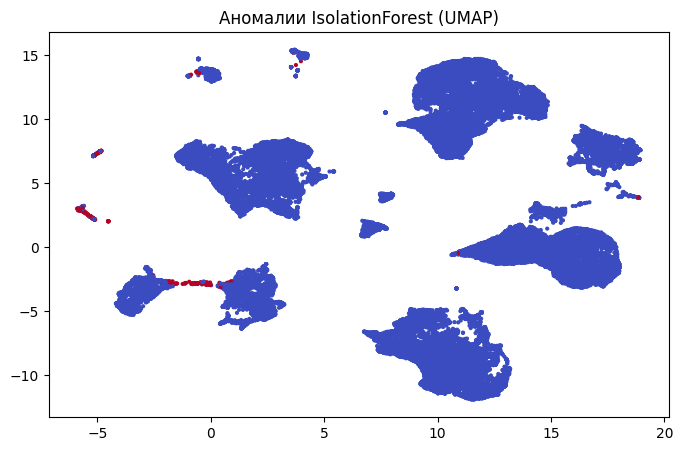

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(X_umap[:,0], X_umap[:,1], c=data2['iso_anomaly'], cmap='coolwarm', s=4)
plt.title('Аномалии IsolationForest (UMAP)')
plt.show()


## Важность признаков (RandomForest)
Обучаем RandomForest и смотрим важности признаков для прогнозирования цены; это помогает понять, какие фичи развивать дальше.

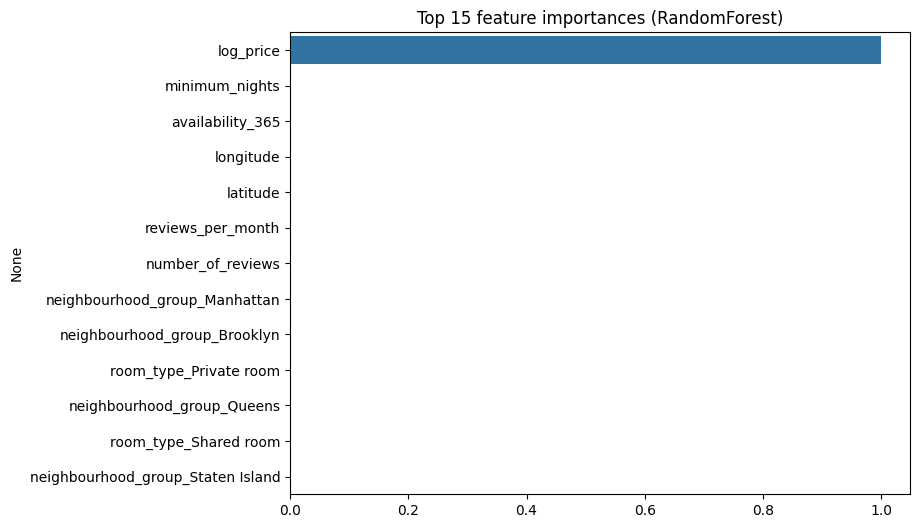

,0
log_price,9.986876e-01
minimum_nights,4.616217e-04
availability_365,3.013627e-04
longitude,1.802041e-04
latitude,1.503473e-04
reviews_per_month,1.163142e-04
number_of_reviews,7.782568e-05
neighbourhood_group_Manhattan,9.387259e-06
neighbourhood_group_Brooklyn,8.194256e-06
room_type_Private room,6.944769e-06


In [33]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# Создание модели Random Forest для регрессии
# -----------------------------
rf = RandomForestRegressor(
    n_estimators=150,   # количество деревьев в лесу (чем больше, тем стабильнее, но медленнее)
    random_state=42,    # фиксируем генератор случайных чисел для воспроизводимости
    n_jobs=-1           # использовать все доступные ядра процессора для ускорения
)

# -----------------------------
# Обучение модели на стандартизированных признаках
# -----------------------------
rf.fit(
    X_scaled,                                # матрица признаков (стандартизированные признаки)
    data_model.loc[X_scaled.index,'price']   # целевая переменная — цена
)

# -----------------------------
# Получение важности признаков
# -----------------------------
importances = pd.Series(
    rf.feature_importances_,  # массив с важностью каждого признака
    index=X_scaled.columns     # подписи признаков
).sort_values(ascending=False)  # сортируем по убыванию важности

# -----------------------------
# Визуализация 15 самых важных признаков
# -----------------------------
plt.figure(figsize=(8,6))  # задаём размер графика
sns.barplot(
    x=importances.values[:15],  # значения важности
    y=importances.index[:15]    # названия признаков
)
plt.title('15 наиболее важных функций (RandomForest)')  # заголовок графика
plt.show()

# -----------------------------
# Вывод топ-20 признаков в виде таблицы
# -----------------------------
display(importances.head(20))  # показываем 20 самых важных признаков с их значениями


Модель Random Forest фактически использует log_price как главный предиктор, остальные признаки имеют символическое влияние.

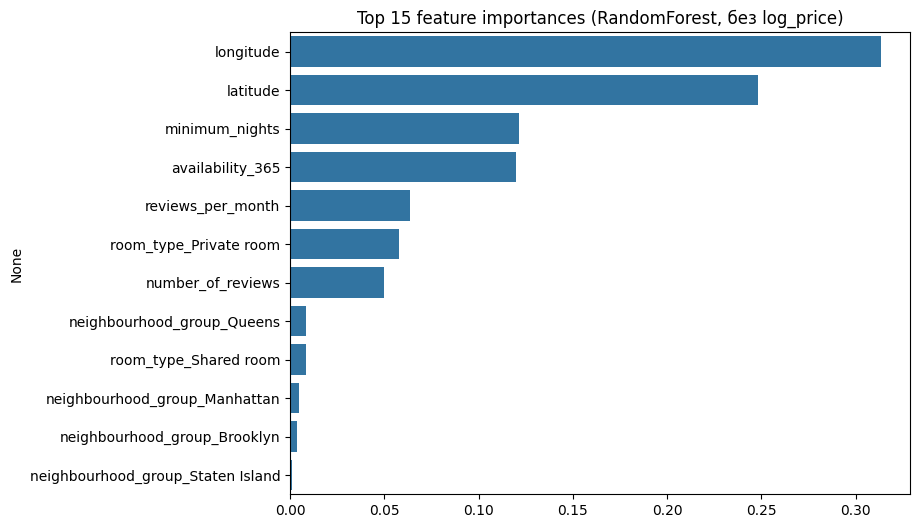

,0
longitude,0.313234
latitude,0.248391
minimum_nights,0.121463
availability_365,0.119743
reviews_per_month,0.063718
room_type_Private room,0.057647
number_of_reviews,0.049907
neighbourhood_group_Queens,0.008430
room_type_Shared room,0.008302
neighbourhood_group_Manhattan,0.004584


In [34]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# Создаём матрицу признаков без log_price
# -----------------------------
X_no_log = X_scaled.drop(columns=['log_price'])

# -----------------------------
# Создаём и обучаем модель Random Forest
# -----------------------------
rf = RandomForestRegressor(
    n_estimators=150,   # количество деревьев
    random_state=42,    # фиксируем случайность
    n_jobs=-1           # использовать все доступные ядра процессора
)
rf.fit(X_no_log, data_model.loc[X_no_log.index,'price'])

# -----------------------------
# Получаем важность признаков
# -----------------------------
importances = pd.Series(rf.feature_importances_, index=X_no_log.columns).sort_values(ascending=False)

# -----------------------------
# Визуализация топ-15 признаков
# -----------------------------
plt.figure(figsize=(8,6))
sns.barplot(x=importances.values[:15], y=importances.index[:15])
plt.title('Top 15 feature importances (RandomForest, без log_price)')
plt.show()

# -----------------------------
# Вывод топ-20 признаков в виде таблицы
# -----------------------------
display(importances.head(20))


- Вывод

Цена зависит в первую очередь от локации и доступности жилья, а также от минимального срока бронирования.

Отзывы и тип комнаты дают умеренный вклад.

Район через one-hot почти не влияет, так как координаты уже содержат ту же информацию.

## Визуализация ошибок и остатки
Сравним предсказания RF с истинными значениями и посмотрим распределение остатков.

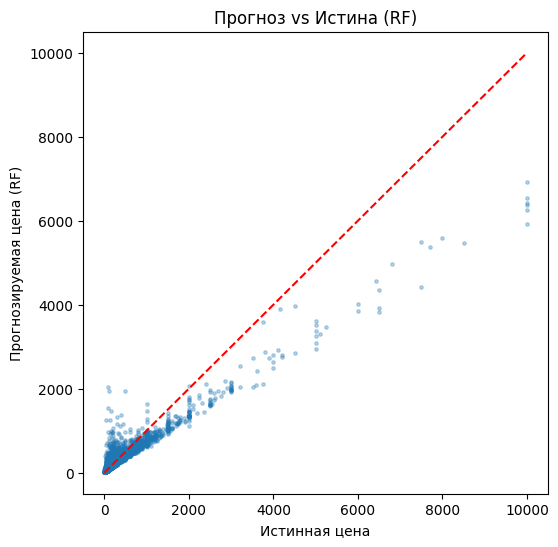

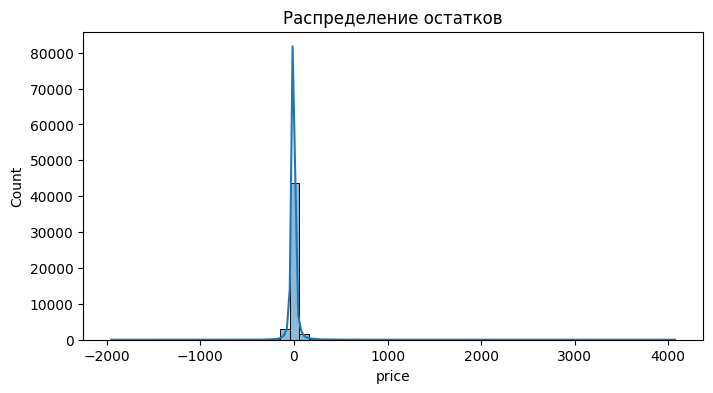

In [39]:
# -----------------------------
# Предсказание цен с помощью обученной модели Random Forest
# -----------------------------
# Предсказание цен на признаках без log_price
y_pred = rf.predict(X_scaled.drop(columns=['log_price']))

# -----------------------------
# Сравнение предсказанных и истинных цен
# -----------------------------
plt.figure(figsize=(6,6))  # размер графика
plt.scatter(
    data_model['price'],  # истинные значения цены
    y_pred,               # предсказанные значения
    alpha=0.3,            # прозрачность точек (чтобы не было слишком темно при наложении)
    s=6                    # размер точек
)
# Красная пунктирная линия y=x для наглядного сравнения
plt.plot(
    [data_model['price'].min(), data_model['price'].max()],
    [data_model['price'].min(), data_model['price'].max()],
    'r--'
)
plt.xlabel('Истинная цена')
plt.ylabel('Прогнозируемая цена (RF)')
plt.title('Прогноз vs Истина (RF)')
plt.show()

# -----------------------------
# Анализ остатков (residuals)
# -----------------------------
residuals = data_model['price'] - y_pred  # остатки = разница между истинной и предсказанной ценой

plt.figure(figsize=(8,4))
sns.histplot(
    residuals,   # распределение остатков
    bins=60,     # количество корзин гистограммы
    kde=True     # отображаем кривую плотности для наглядности
)
plt.title('Распределение остатков')
plt.show()
